In [1]:
from ssf.Constants import *
from ssf.Taxonomy import Taxonomy
import pandas as pd
from ast import literal_eval
from ssf.community_preprocessors.SubredditPreprocessor import SubredditPreprocessor
import numpy as np
from ssf.utils import ResultsVisUtils
from ssf.utils.TaxonomyDataUtils import (
    prepare_dataframe_for_varvals,
    build_varvals_list,
    get_sublabel_support,
    filter_sublabels,
    canonicalize_cats,
    get_tc_analysis_df,
    get_cats_col_name,
    add_is_in_ml_df_col
)
from collections import defaultdict
from ssf.metric_executors import MultiPredMetricExecutor
from ssf.RatingOptions import RatingOptions
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import cohen_kappa_score
from ssf.helpers import map_moral_values
from ssf.generation_strategies.configs import ModelConfig, GenerationConfig
from ssf.generation_strategies import OpenaiGenerationStrategy
from ssf.Configs import load_config
from ssf.Constants import REPLICATION_CONFIG_PATH
from ssf.ssf_sim import CommunitySsfSim
from ssf.ssf_sim.data_utils import (
    build_community_sublabel_counts,
    build_community_varvals_list
)
from ssf.utils.NpmiUtils import compute_npmi

[nltk_data] Downloading package stopwords to /home/jmire/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/home/jmire/ssf/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config = load_config(REPLICATION_CONFIG_PATH)

# Method
### Context Summarization

### SSF-Generator REF (GPT-4.1) Generations
#### compared to Prolific human-written responses

In [3]:
taxonomy = Taxonomy(TAXONOMY_DIR)
ssf_split_test_path = f"{config.dirs.data.corpus}/ssf_split_test.csv"
ssf_split_test_df = pd.read_csv(ssf_split_test_path)

hw_ann_df = pd.read_csv(HUMAN_WRITTEN_INFS_PATH, sep="\t")
hw_ann_df = hw_ann_df[hw_ann_df["instance_id"] != CONSENT_ID]

ssf_split_test_df_trimmed = ssf_split_test_df[ssf_split_test_df['id'].isin(hw_ann_df['instance_id'])]
hw_ann_df_trimmed = hw_ann_df[hw_ann_df['instance_id'].isin(ssf_split_test_df['id'])]

print("ref_stories_df shape", ssf_split_test_df.shape)
print("ref_stories_df_trimmed shape", ssf_split_test_df_trimmed.shape)
print("hw_ann_df shape", hw_ann_df.shape)
print("hw_ann_df_trimmed shape", hw_ann_df_trimmed.shape)
print("ref_stories_df_trimmed columns", ssf_split_test_df_trimmed.columns.tolist())
print("hw_ann_df_trimmed columns", hw_ann_df_trimmed.columns.tolist())

ref_stories_df shape (297, 132)
ref_stories_df_trimmed shape (56, 132)
hw_ann_df shape (80, 15)
hw_ann_df_trimmed shape (74, 15)
ref_stories_df_trimmed columns ['timestamp', 'speaker', 'reply_to', 'conversation_id', 'meta.score', 'meta.retrieved_on', 'meta.gilded', 'meta.gildings', 'meta.subreddit', 'meta.stickied', 'meta.permalink', 'meta.author_flair_text', 'meta.ancestralUttIds', 'meta.prevUttIds', 'meta.storySeeker', 'meta.perspective', 'meta.summary', 'meta.subredditDescription', 'meta.subredditValues', 'meta.progenitorContext', 'meta.ancestralContext', 'meta.previousContext', 'meta.conversationContext', 'meta.communityDescription', 'meta.communityValues', 'vectors', 'id', 'label_suggestions', 'split', 'gpt_4o_2024_11_20_overall_goal_gen0', 'gpt_4o_2024_11_20_overall_goal_gen1', 'gpt_4o_2024_11_20_overall_goal_gen2', 'gpt_4o_2024_11_20_narrative_intent_gen0', 'gpt_4o_2024_11_20_narrative_intent_gen1', 'gpt_4o_2024_11_20_narrative_intent_gen2', 'gpt_4o_2024_11_20_author_emotional_r

In [4]:
# Helper function to prepare DataFrames with multiple response samples
def process_multiple_samples(df, taxonomy, instance_id_col, response_col_prefix, response_col_suffixes, response_col_is_only_suffix=False):
    """
    Process a DataFrame with multiple response samples per instance.
    
    For data with multiple samples (e.g., _gen0, _gen1, _gen2), this function
    processes each sample separately and combines the results.
    
    Args:
        df: Input DataFrame
        taxonomy: Taxonomy instance
        instance_id_col: Column name for instance IDs
        response_col_prefix: Prefix for response columns (e.g., "gpt_4o_2024_11_20_")
        response_col_suffixes: List of suffixes (e.g., ["_gen0", "_gen1", "_gen2"])
        response_col_is_only_suffix: If True, use POTATO format (prepend template prefix)
    
    Returns:
        Tuple of (varvals_dict, quality_stats)
    """
    all_varvals = defaultdict(list)
    all_quality_stats = []
    
    for suffix in response_col_suffixes:
        # Prepare DataFrame with standard column names for this suffix
        df_prepared = prepare_dataframe_for_varvals(
            df=df,
            taxonomy=taxonomy,
            response_col_prefix=response_col_prefix,
            response_col_suffix=suffix,
            response_col_is_only_suffix=response_col_is_only_suffix
        )
        
        # Extract varvals using generic function
        varvals_dict, quality_stats = build_varvals_list(
            df=df_prepared,
            taxonomy=taxonomy,
            instance_id_col=instance_id_col,
            return_quality_stats=True
        )
        
        # Combine results from this suffix
        for key, values in varvals_dict.items():
            all_varvals[key].extend(values)
        
        all_quality_stats.append(quality_stats)
    
    # Average quality stats across all suffixes
    if all_quality_stats:
        avg_quality_stats = {
            key: sum(stats[key] for stats in all_quality_stats) / len(all_quality_stats)
            for key in all_quality_stats[0].keys()
        }
    else:
        avg_quality_stats = {}
    
    return dict(all_varvals), avg_quality_stats

In [5]:
# Process human-written annotations
hw_idDim_varValsList_dict, hw_quality_stats = process_multiple_samples(
    df=hw_ann_df_trimmed,
    taxonomy=taxonomy,
    instance_id_col="instance_id",
    response_col_prefix="",
    response_col_suffixes=[":::text_box"],
    response_col_is_only_suffix=True
)
print("HW Quality Stats", hw_quality_stats)
print()

# Process GPT-4o generations
promptColSuffix_idDim_varValsList_dict = defaultdict(lambda: defaultdict(list))
for prompt_col_suffix in [PROMPT_COL_SUFFIX_FULL_CONTEXT]:
    print(ssf_split_test_df_trimmed.columns.tolist())
    idDimVarValsList_dict, quality_stats = process_multiple_samples(
        df=ssf_split_test_df_trimmed,
        taxonomy=taxonomy,
        instance_id_col="id",
        response_col_prefix="gpt_4o_2024_11_20_",
        response_col_suffixes=[f"_gen{idx}" for idx in range(3)],
        response_col_is_only_suffix=False
    )
    promptColSuffix_idDim_varValsList_dict[prompt_col_suffix] = idDimVarValsList_dict
    print(f"{prompt_col_suffix} Quality Stats:", quality_stats)
    print()

multi_pred_metric_executor = MultiPredMetricExecutor(sbert_model=config.models.sbert_model)

def get_dim_metricsDict_dict(pred_idDim_varValsList_dict, 
                             ref_idDim_varValsList_dict):
    dim_metricsDict_dict = defaultdict(lambda: defaultdict(list))
    for ref_key, refs_varVals in ref_idDim_varValsList_dict.items():
        if ref_key not in pred_idDim_varValsList_dict:
            print(f"Ref key {ref_key} not in pred_idDim_varValsList_dict, skipping.")
            continue
        preds_varVals = pred_idDim_varValsList_dict[ref_key]
        _, dim = ref_key
        dim_metricsDict_dict[dim]['cosine_similarity'].append(multi_pred_metric_executor.cosine_similarity(preds_varVals=preds_varVals, 
                                                                                                           refs_varVals=refs_varVals, 
                                                                                                           preds_agg_strategy="avg", 
                                                                                                           refs_agg_strategy="max"))
        dim_metricsDict_dict[dim]['bert_score'].append(multi_pred_metric_executor.bert_score(preds_varVals=preds_varVals, 
                                                                                         refs_varVals=refs_varVals, 
                                                                                         preds_agg_strategy="avg", 
                                                                                         refs_agg_strategy="max"))
        dim_metricsDict_dict[dim]['bleu'].append(multi_pred_metric_executor.bleu(preds_varVals=preds_varVals, 
                                                                             refs_varVals=refs_varVals, 
                                                                             preds_agg_strategy="avg"))
        dim_metricsDict_dict[dim]['meteor'].append(multi_pred_metric_executor.meteor(preds_varVals=preds_varVals, 
                                                                                 refs_varVals=refs_varVals, 
                                                                                 preds_agg_strategy="avg"))
    
    return dim_metricsDict_dict
    
def get_dim_agg_metrics(dim_metricsDict_dict):
    dim_agg_metrics = defaultdict(lambda: defaultdict(float))
    for dim in taxonomy.get_dims():
        metricsDict = dim_metricsDict_dict[dim]
        for metric_name, values in metricsDict.items():
            if len(values) > 0:
                dim_agg_metrics[dim][metric_name] = np.mean(values)
                dim_agg_metrics[dim]["n"] = len(values)
    return dim_agg_metrics

def get_overall_metrics(dim_metricsDict_dict):
    metricName_scores = defaultdict(list)
    metricName_counts = defaultdict(int)
    for metricsDict in dim_metricsDict_dict.values():
        for metric_name, values in metricsDict.items():
            metricName_scores[metric_name].extend(values)
    for metricName, scores in metricName_scores.items():
        metricName_scores[metricName] = np.mean(scores)
        metricName_counts[metricName] = len(scores)
    return metricName_scores, metricName_counts

# Compute metrics
promptColSuffix_autoResultsDict_dict = defaultdict(dict)
for prompt_col_suffix, pred_idDim_varValsList_dict in promptColSuffix_idDim_varValsList_dict.items():
    print(f"Prompt col suffix: {prompt_col_suffix}")
    dim_metricsDict_dict = get_dim_metricsDict_dict(pred_idDim_varValsList_dict, hw_idDim_varValsList_dict)
    dim_aggMetricsDict_dict = get_dim_agg_metrics(dim_metricsDict_dict)
    metricName_overallScore_dict = defaultdict(list)
    for metricName in ['cosine_similarity', 'bert_score', 'bleu', 'meteor']:
        aggDimScores = [aggDimScores[metricName] for aggDimScores in dim_aggMetricsDict_dict.values()]
        metricName_overallScore_dict[metricName] = np.mean(aggDimScores)
  
    print("Overall metrics:", metricName_overallScore_dict)
    promptColSuffix_autoResultsDict_dict[prompt_col_suffix]['dim_aggMetricsDict_dict'] = dim_aggMetricsDict_dict
    promptColSuffix_autoResultsDict_dict[prompt_col_suffix]['metricName_overallScore_dict'] = metricName_overallScore_dict

# Generate and display the LaTeX table
latex_table = ResultsVisUtils.gpt4o_x_prolific_hw(promptColSuffix_autoResultsDict_dict[prompt_col_suffix], out_path=f"{PLAUSIBILITY_RESULTS_DIR}/gpt4o_x_prolific_hw.csv")
print(latex_table)

HW Quality Stats {'invalid_fmt rate': 0.05540540540540541, 'unmodified rate': 0.0972972972972973, 'quality rate': 0.8472972972972973}

['timestamp', 'speaker', 'reply_to', 'conversation_id', 'meta.score', 'meta.retrieved_on', 'meta.gilded', 'meta.gildings', 'meta.subreddit', 'meta.stickied', 'meta.permalink', 'meta.author_flair_text', 'meta.ancestralUttIds', 'meta.prevUttIds', 'meta.storySeeker', 'meta.perspective', 'meta.summary', 'meta.subredditDescription', 'meta.subredditValues', 'meta.progenitorContext', 'meta.ancestralContext', 'meta.previousContext', 'meta.conversationContext', 'meta.communityDescription', 'meta.communityValues', 'vectors', 'id', 'label_suggestions', 'split', 'gpt_4o_2024_11_20_overall_goal_gen0', 'gpt_4o_2024_11_20_overall_goal_gen1', 'gpt_4o_2024_11_20_overall_goal_gen2', 'gpt_4o_2024_11_20_narrative_intent_gen0', 'gpt_4o_2024_11_20_narrative_intent_gen1', 'gpt_4o_2024_11_20_narrative_intent_gen2', 'gpt_4o_2024_11_20_author_emotional_response_gen0', 'gpt_4o_20

[nltk_data] Downloading package wordnet to /home/jmire/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/jmire/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/jmire/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Prompt col suffix: prompt_default


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Ref key ('e6a8us5', 'stance') not in pred_idDim_varValsList_dict, skipping.
Overall metrics: defaultdict(<class 'list'>, {'cosine_similarity': 0.3986772638694875, 'bert_score': 0.8661226473129485, 'bleu': 0.20061003589132403, 'meteor': 0.14814543811951705})
\begin{table*}[h]
\small
\centering
\begin{tabular}{lccccc}
\toprule
Dimension & Cosine Sim. & BERTScore & BLEU & METEOR & N \\
\midrule
overall\_goal & 0.403 & 0.862 & 0.095 & 0.147 & 54 \\
narrative\_intent & 0.368 & 0.862 & 0.097 & 0.127 & 54 \\
author\_emotional\_response & 0.300 & 0.861 & 0.231 & 0.070 & 54 \\
character\_appraisal & 0.568 & 0.889 & 0.480 & 0.210 & 48 \\
causal\_explanation & 0.394 & 0.866 & 0.118 & 0.170 & 41 \\
prediction & 0.460 & 0.878 & 0.335 & 0.244 & 45 \\
stance & 0.540 & 0.903 & 0.381 & 0.232 & 45 \\
moral & 0.388 & 0.855 & 0.071 & 0.113 & 54 \\
narrative\_feeling & 0.313 & 0.839 & 0.067 & 0.089 & 54 \\
aesthetic\_feeling & 0.252 & 0.847 & 0.130 & 0.081 & 45 \\
\midrule
Overall & 0.399 & 0.866 & 0.201 &

##### GPT4.1 Plausibility Ratings from Prolific human annotators

In [6]:
def should_exclude_row(row, swapped_dim):
    """Determine if a row should be excluded from analysis."""
    implausible_col = f"{swapped_dim}:::{RatingOptions.IMPLAUSIBLE}"
    unlikely_col = f"{swapped_dim}:::{RatingOptions.SOMEWHAT_UNLIKELY}"
    return (row.get(implausible_col) != implausible_col) and (row.get(unlikely_col) != unlikely_col) 

def collect_ratings(row, dim_preds, swapped_dim, taxonomy):
    """Collect ratings for each dimension except swapped dimension."""
    for dim in taxonomy.get_dims():
        if dim == swapped_dim:
            continue
            
        for rating_option in RatingOptions.all():
            col = f"{dim}:::{rating_option}"
            if row.get(col) == col:
                dim_preds[dim].append(RatingOptions.scores()[rating_option])

def process_ratings(ratings_df, stories_df, taxonomy):
    """Process ratings data and return dimension predictions, exclusion count, and valid user IDs."""
    dim_preds = {dim: [] for dim in taxonomy.get_dims()}
    excluded_count = 0
    valid_user_ids = set()
    
    for _, row in ratings_df.iterrows():
        story = stories_df.loc[stories_df['id'] == row['instance_id']]
        if story.empty:
            print(f"No matching story found for instance_id: {row['instance_id']}")
            continue
        swapped_dim = story['swap_dim'].values[0]

        if should_exclude_row(row, swapped_dim):
            excluded_count += 1
            continue
            
        valid_user_ids.add(row['user'])
        collect_ratings(row, dim_preds, swapped_dim, taxonomy)
            
    return dim_preds, excluded_count, valid_user_ids

def calculate_statistics(dim_preds):
    """Calculate statistics from dimension predictions."""
    all_scores = [score for scores in dim_preds.values() for score in scores]
    
    if not all_scores:
        return None, None, None, None, None
    
    average_score_overall = sum(all_scores) / len(all_scores)
    std_dev_overall = np.std(all_scores, ddof=1)
    
    average_score_by_dim = {dim: sum(scores) / len(scores) if scores else 0 
                           for dim, scores in dim_preds.items()}
    
    std_dev_by_dim = {dim: np.std(scores, ddof=1) if scores else 0 
                     for dim, scores in dim_preds.items()}
    
    score_counts = {i: all_scores.count(i) for i in range(1, 5)}
    score_proportions = {i: count / len(all_scores) for i, count in score_counts.items()}
    
    return average_score_overall, std_dev_overall, average_score_by_dim, std_dev_by_dim, score_proportions

def calculate_dimension_proportions(dim_preds):
    """Calculate score proportions for each dimension."""
    dim_proportions = {}
    
    for dim, scores in dim_preds.items():
        if not scores:
            dim_proportions[dim] = {i: 0 for i in range(1, 5)}
            continue
            
        score_counts = {i: scores.count(i) for i in range(1, 5)}
        dim_proportions[dim] = {i: count / len(scores) for i, count in score_counts.items()}
    
    return dim_proportions

def process_dataset(annotations_path: str, stories_df: pd.DataFrame, taxonomy, dataset_name: str):
    """Process a single dataset and return results."""
    print(f"\nProcessing {dataset_name}...")
    
    ratings_df = pd.read_csv(annotations_path, sep="\t")
    ratings_df = ratings_df[ratings_df["instance_id"] != CONSENT_ID]
    
    ratings_df_trimmed = ratings_df[ratings_df['instance_id'].isin(stories_df['id'])]
    
    print(f"{dataset_name} - ratings_df shape: {ratings_df.shape}")
    print(f"{dataset_name} - ratings_df_trimmed shape: {ratings_df_trimmed.shape}")
    
    dim_preds, excluded_count, valid_user_ids = process_ratings(
        ratings_df=ratings_df_trimmed,
        stories_df=stories_df,
        taxonomy=taxonomy
    )
    
    stats = calculate_statistics(dim_preds)
    
    if stats[0] is None:
        print(f"No valid data to analyze for {dataset_name}")
        return None
    
    avg_overall, std_overall, avg_by_dim, std_by_dim, proportions = stats
    dim_proportions = calculate_dimension_proportions(dim_preds)
    
    # Print statistics
    print(f"{dataset_name} - Average Score (Overall): {avg_overall:.2f} ± {std_overall:.2f}")
    print(f"{dataset_name} - Score Statistics by Dimension:")
    for dim in avg_by_dim:
        print(f"  - {dim}: {avg_by_dim[dim]:.2f} ± {std_by_dim[dim]:.2f} (n={len(dim_preds[dim])})")
    
    print(f"{dataset_name} - Proportions: {proportions}")
    print(f"{dataset_name} - Exclusion Rate: {excluded_count / len(ratings_df_trimmed):.2f}")
    print(f"{dataset_name} - Number of unique users with valid data: {len(valid_user_ids)}")
    
    return {
        'dim_preds': dim_preds,
        'stats': stats,
        'dim_proportions': dim_proportions,
        'excluded_count': excluded_count,
        'valid_user_ids': valid_user_ids,
        'total_ratings': len(ratings_df_trimmed)
    }

def calculate_overall_proportions(dim_preds):
    """Calculate overall proportions across all dimensions."""
    all_scores = [score for scores in dim_preds.values() for score in scores]
    
    if not all_scores:
        return {i: 0 for i in range(1, 5)}
    
    score_counts = {i: all_scores.count(i) for i in range(1, 5)}
    overall_proportions = {i: count / len(all_scores) for i, count in score_counts.items()}
    
    return overall_proportions


# Load reference stories once
print(f"Reference stories shape: {ssf_split_test_df.shape}")

# Process both datasets
results = {}
results['Model 1'] = process_dataset(GPT4O_INF_PLAUSIBILITY_RATINGS_PATH, ssf_split_test_df, taxonomy, 'Model 1')
results['Model 2'] = process_dataset(SSF_GEN_INF_PLAUSIBILITY_RATINGS_PATH, ssf_split_test_df, taxonomy, 'Model 2')

# Filter out any failed datasets
results = {name: data for name, data in results.items() if data is not None}

if len(results) < 2:
    print("Error: Need at least two valid datasets for comparison")
    exit(1)

# Get dimensions from taxonomy
dimensions = taxonomy.get_dims()

# Print comparison summary
print("\n" + "="*50)
print("COMPARISON SUMMARY")
print("="*50)

for dataset_name, data in results.items():
    avg_overall = data['stats'][0]
    exclusion_rate = data['excluded_count'] / data['total_ratings']
    print(f"{dataset_name}:")
    print(f"  Overall Average: {avg_overall:.2f}")
    print(f"  Exclusion Rate: {exclusion_rate:.2f}")
    print(f"  Valid Users: {len(data['valid_user_ids'])}")
    print()

Reference stories shape: (297, 132)

Processing Model 1...
Model 1 - ratings_df shape: (624, 45)
Model 1 - ratings_df_trimmed shape: (590, 45)
Model 1 - Average Score (Overall): 3.09 ± 0.87
Model 1 - Score Statistics by Dimension:
  - overall_goal: 3.21 ± 0.93 (n=405)
  - narrative_intent: 3.28 ± 0.83 (n=418)
  - author_emotional_response: 2.86 ± 0.90 (n=424)
  - character_appraisal: 2.93 ± 0.92 (n=438)
  - causal_explanation: 3.14 ± 0.90 (n=411)
  - prediction: 3.09 ± 0.77 (n=424)
  - stance: 3.08 ± 0.85 (n=442)
  - moral: 3.14 ± 0.86 (n=435)
  - narrative_feeling: 3.07 ± 0.82 (n=417)
  - aesthetic_feeling: 3.10 ± 0.81 (n=425)
Model 1 - Proportions: {1: 0.05826845954234489, 2: 0.15970747817881575, 3: 0.4166076904930408, 4: 0.36541637178579855}
Model 1 - Exclusion Rate: 0.20
Model 1 - Number of unique users with valid data: 278

Processing Model 2...
Model 2 - ratings_df shape: (222, 45)
Model 2 - ratings_df_trimmed shape: (222, 45)
Model 2 - Average Score (Overall): 3.17 ± 0.88
Model 

In [7]:
# Inter-Annotator Agreement (IAA) Analysis
# Computes percent agreement between annotators who annotated the same story
# Based on the code from __prolific_rating_analysis.ipynb

# Ordinal and binary mappings for IAA computation (from RatingOptions class)
ORD_MAP = RatingOptions.ordinal_map()
BIN_MAP = RatingOptions.binary_map()

# Load taxonomy
taxonomy = Taxonomy(TAXONOMY_DIR)

# Results directories with multiple annotators per story
RATING_PATHS = [
    (GPT4O_INF_PLAUSIBILITY_RATINGS_PATH, ssf_split_test_path),
    (SSF_GEN_INF_PLAUSIBILITY_RATINGS_PATH, ssf_split_test_path)
]

def load_data(ratings_path, stories_path):
    """Load ratings and stories data."""
    ratings_df = pd.read_csv(ratings_path, sep='\t')
    stories_df = pd.read_csv(stories_path)
    
    # Filter out consent rows
    ratings_df = ratings_df[ratings_df['instance_id'] != CONSENT_ID]
    
    return ratings_df, stories_df

def row_passes_swap_check(row, swapped_dim):
    """True ⇔ annotator marked swapped dimension implausible / somewhat-unlikely."""
    implausible_col = f"{swapped_dim}:::{RatingOptions.IMPLAUSIBLE}"
    unlikely_col    = f"{swapped_dim}:::{RatingOptions.SOMEWHAT_UNLIKELY}"
    return (row.get(implausible_col) == implausible_col) or \
           (row.get(unlikely_col)    == unlikely_col)

def get_rating(row, dim):
    """Return the string rating for *dim* (None if nothing selected)."""
    for opt in RatingOptions.all():
        col = f"{dim}:::{opt}"
        if row.get(col) == col:
            return opt
    return None

def agreement_stats(ratings_df, stories_df, taxonomy, weight_type="quadratic"):
    """
    Compute Inter-Annotator Agreement statistics.
    Returns:
        kappa_w    : quadratic-weighted κ on 4 grades
        n_pairs    : # label pairs that went into κ
        pct_agree4 : raw agreement on the 4-grade scale
        pct_agree2 : raw agreement on the binary scale
        pct_within1: percent agreement within 1 scale point
        story_count: number of stories with multiple annotators
    """
    lab4_a, lab4_b = [], []   # original 4-grade labels (ordinal 0–3)
    lab2_a, lab2_b = [], []   # binarised labels (0/1)
    stories_with_multiple_annotators = 0

    # Process each instance_id (story)
    for iid, grp in ratings_df.groupby("instance_id"):
        # Only include stories with exactly 2 annotators
        if len(grp) != 2:
            continue
            
        stories_with_multiple_annotators += 1
        row1, row2 = grp.iloc[0], grp.iloc[1]

        # Get swap dimension for this story
        swap_series = stories_df.loc[stories_df["id"] == iid, "swap_dim"]
        if swap_series.empty:
            # print("THIS SHOULDN:T HAPPEN")
            continue
        swapped_dim = swap_series.values[0]

        # Check if both annotators passed the swap check
        if not (row_passes_swap_check(row1, swapped_dim) and
                row_passes_swap_check(row2, swapped_dim)):
            continue

        # Collect ratings for all dimensions (including swapped dimension for full analysis)
        for dim in taxonomy.get_dims():
            r1, r2 = get_rating(row1, dim), get_rating(row2, dim)
            if (r1 is None) or (r2 is None):
                continue
            lab4_a.append(ORD_MAP[r1]); lab4_b.append(ORD_MAP[r2])
            lab2_a.append(BIN_MAP[r1]); lab2_b.append(BIN_MAP[r2])

    n_pairs = len(lab4_a)
    if n_pairs == 0:
        return None, 0, None, None, None, stories_with_multiple_annotators

    kappa_w    = cohen_kappa_score(lab4_a, lab4_b, weights=weight_type)
    pct_agree4 = sum(a == b for a, b in zip(lab4_a, lab4_b)) / n_pairs
    pct_agree2 = sum(a == b for a, b in zip(lab2_a, lab2_b)) / n_pairs
    pct_within1 = sum(abs(a - b) <= 1 for a, b in zip(lab4_a, lab4_b)) / n_pairs

    return kappa_w, n_pairs, pct_agree4, pct_agree2, pct_within1, stories_with_multiple_annotators

# Run IAA analysis for each results directory
print("=== Inter-Annotator Agreement Analysis ===")
print("Computing agreement between annotators who annotated the same story...\n")

for ratings_path, stories_path in RATING_PATHS:
    print(f"Processing {ratings_path}...")
    ratings_df, stories_df = load_data(ratings_path, stories_path)
    
    # Check how many stories have multiple annotators
    story_counts = ratings_df['instance_id'].value_counts()
    multiple_annotators = (story_counts >= 2).sum()
    total_stories = len(story_counts)
    
    print(f"  Total stories: {total_stories}")
    print(f"  Stories with multiple annotators: {multiple_annotators}")

    kappa_w, n_pairs, pct4, pct2, pct_within1, stories_processed = agreement_stats(
        ratings_df, stories_df, taxonomy, weight_type="quadratic"
    )

    if kappa_w is None:
        print(f"  No eligible annotation pairs – κ undefined.\n")
        continue

    print(f"  Stories successfully processed for IAA: {stories_processed}")
    print(f"  Quadratic-weighted κ (4 grades): {kappa_w:.3f} (n = {n_pairs} annotation pairs)")
    print(f"  Percent agreement 4-grade scale: {pct4*100:5.1f}%")
    print(f"  Percent agreement binary scale:  {pct2*100:5.1f}%")
    print(f"  Percent within-1 agreement:      {pct_within1*100:5.1f}%")
    print()

print("=== Analysis Notes ===")
print("- Only stories with exactly 2 annotators are included")
print("- Annotators must pass the swap check (mark swapped dimension as implausible/unlikely)")
print("- 4-grade scale: implausible(0), unlikely(1), likely(2), very likely(3)")
print("- Binary scale: implausible/unlikely(0) vs likely/very likely(1)")
print("- Within-1: agreements where ratings differ by at most 1 scale point")
print("- κ weights: quadratic (penalizes distant disagreements more)")

=== Inter-Annotator Agreement Analysis ===
Computing agreement between annotators who annotated the same story...

Processing ../data/replication/annotations/prolific/gpt4o_inf_plausibility_ratings.tsv...
  Total stories: 315
  Stories with multiple annotators: 309
  Stories successfully processed for IAA: 309
  Quadratic-weighted κ (4 grades): 0.375 (n = 1920 annotation pairs)
  Percent agreement 4-grade scale:  37.8%
  Percent agreement binary scale:   71.0%
  Percent within-1 agreement:       84.3%

Processing ../data/replication/annotations/prolific/ssf_generator_inf_plausibility_ratings.tsv...
  Total stories: 114
  Stories with multiple annotators: 108
  Stories successfully processed for IAA: 108
  Quadratic-weighted κ (4 grades): 0.429 (n = 760 annotation pairs)
  Percent agreement 4-grade scale:  46.6%
  Percent agreement binary scale:   77.0%
  Percent within-1 agreement:       85.3%

=== Analysis Notes ===
- Only stories with exactly 2 annotators are included
- Annotators mu

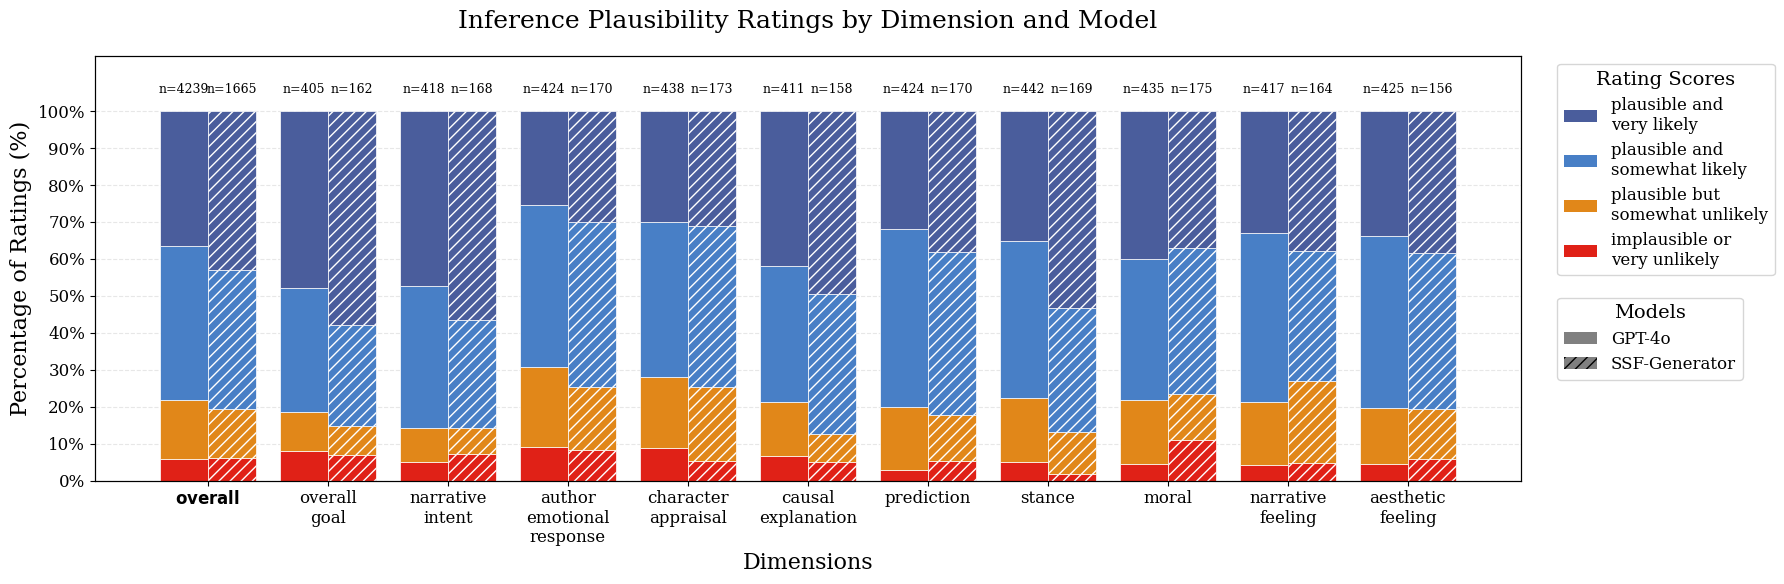

In [8]:
ResultsVisUtils.plot_option_1_hatching(results, dimensions, f"{PLAUSIBILITY_RESULTS_DIR}/plausibility_ratings_hatching.pdf")

### Analyses
##### Big-Picture Overview of Frequency Distributions

In [9]:
def get_default_openai_generation_strategy(config):
  model_config = ModelConfig(model_name=config.models.openai_default)
  generation_config = GenerationConfig()
  return OpenaiGenerationStrategy(model_config=model_config,
                                  generation_config=generation_config)

default_openai_generation_strategy = get_default_openai_generation_strategy(config)
subreddit_preprocessor = SubredditPreprocessor(subreddits_path=SUBREDDITS_PATH,
                                                                      subreddit_desc_rules_path=SUBREDDIT_DESC_RULES_PATH,
                                                                      dir=config.dirs.data.subreddit_metadata,
                                                                      generation_strategy=default_openai_generation_strategy,
                                                                      force_rebuild=False)

subreddit_topic_dict = subreddit_preprocessor.get_community_topic_dict()
print(len(set(subreddit_topic_dict.values())))
print(list(subreddit_topic_dict.values()))
# subreddit_commArchs_dict = subreddit_preprocessor.get_subreddit_commArchs_dict()
# print(list(subreddit_commArchs_dict.items())[:5])

15
['Humor', 'Learning', 'Games', 'News', 'Learning', 'Music', 'Entertainment', 'Learning', 'News', 'Learning', 'Learning', 'Learning', 'Learning', 'Meta', 'Meta', 'Technology and Science', 'Support', 'Sports', 'Hobby', 'Support', 'Entertainment', 'Sports', 'Humor', 'Politics', 'Sports', 'Learning', 'Technology and Science', 'Hobby', 'Technology and Science', 'Hobby', 'Fashion', 'Learning', 'Technology and Science', 'Learning', 'Politics', 'Entertainment', 'Sports', 'Hobby', 'Games', 'Sports', 'Sports', 'Entertainment', 'Entertainment', 'Technology and Science', 'Support', 'Video Games', 'Technology and Science', 'Sports', 'Sports', 'Local', 'Local', 'Sports', 'News', 'Support', 'Support', 'Learning']


In [10]:
def get_full_df_converters(taxonomy):
  _full_df_list_cols = [get_cats_col_name(PROMPT_COL_SUFFIX_FULL_CONTEXT, dim, "gen0") for dim in taxonomy.get_dims()]
  return {col: literal_eval for col in _full_df_list_cols}

# load the df with ~2k stories used for training/val/test
ssf_split_df = pd.read_csv(f"{config.dirs.data.corpus}/ssf_split.csv")
print(ssf_split_df['split'].value_counts())

# load the df with ~6k stories, which is not stratified across subreddits
ssf_df = pd.read_csv(f"{config.dirs.data.corpus}/{SSF_DF_PATH}", converters=get_full_df_converters(taxonomy))

print(ssf_df.columns.tolist())
# add column to full_df indicating whether story is also in ml_df
ssf_df = add_is_in_ml_df_col(ssf_df, ssf_split_df)

# build tc_analysis_df
tc_analysis_df = get_tc_analysis_df(full_df=ssf_df,
                                    taxonomy=taxonomy)
tc_analysis_df.to_csv(f"{config.dirs.data.analysis}/tc.csv", index=False)

split
train    1184
val       297
test      297
Name: count, dtype: int64
['id', 'timestamp', 'speaker', 'reply_to', 'conversation_id', 'meta.score', 'meta.retrieved_on', 'meta.gilded', 'meta.gildings', 'meta.subreddit', 'meta.stickied', 'meta.permalink', 'meta.author_flair_text', 'meta.ancestralUttIds', 'meta.prevUttIds', 'meta.storySeeker', 'meta.perspective', 'meta.summary', 'meta.subredditDescription', 'meta.subredditValues', 'meta.progenitorContext', 'meta.ancestralContext', 'meta.previousContext', 'meta.conversationContext', 'meta.communityDescription', 'meta.communityValues', 'vectors', 'label_suggestions', 'split', 'prompt_default$overall_goal_gen0', 'prompt_default$narrative_intent_gen0', 'prompt_default$author_emotional_response_gen0', 'prompt_default$character_appraisal_gen0', 'prompt_default$causal_explanation_gen0', 'prompt_default$prediction_gen0', 'prompt_default$stance_gen0', 'prompt_default$moral_gen0', 'prompt_default$narrative_feeling_gen0', 'prompt_default$aesthetic

Creating side-by-side comparisons...


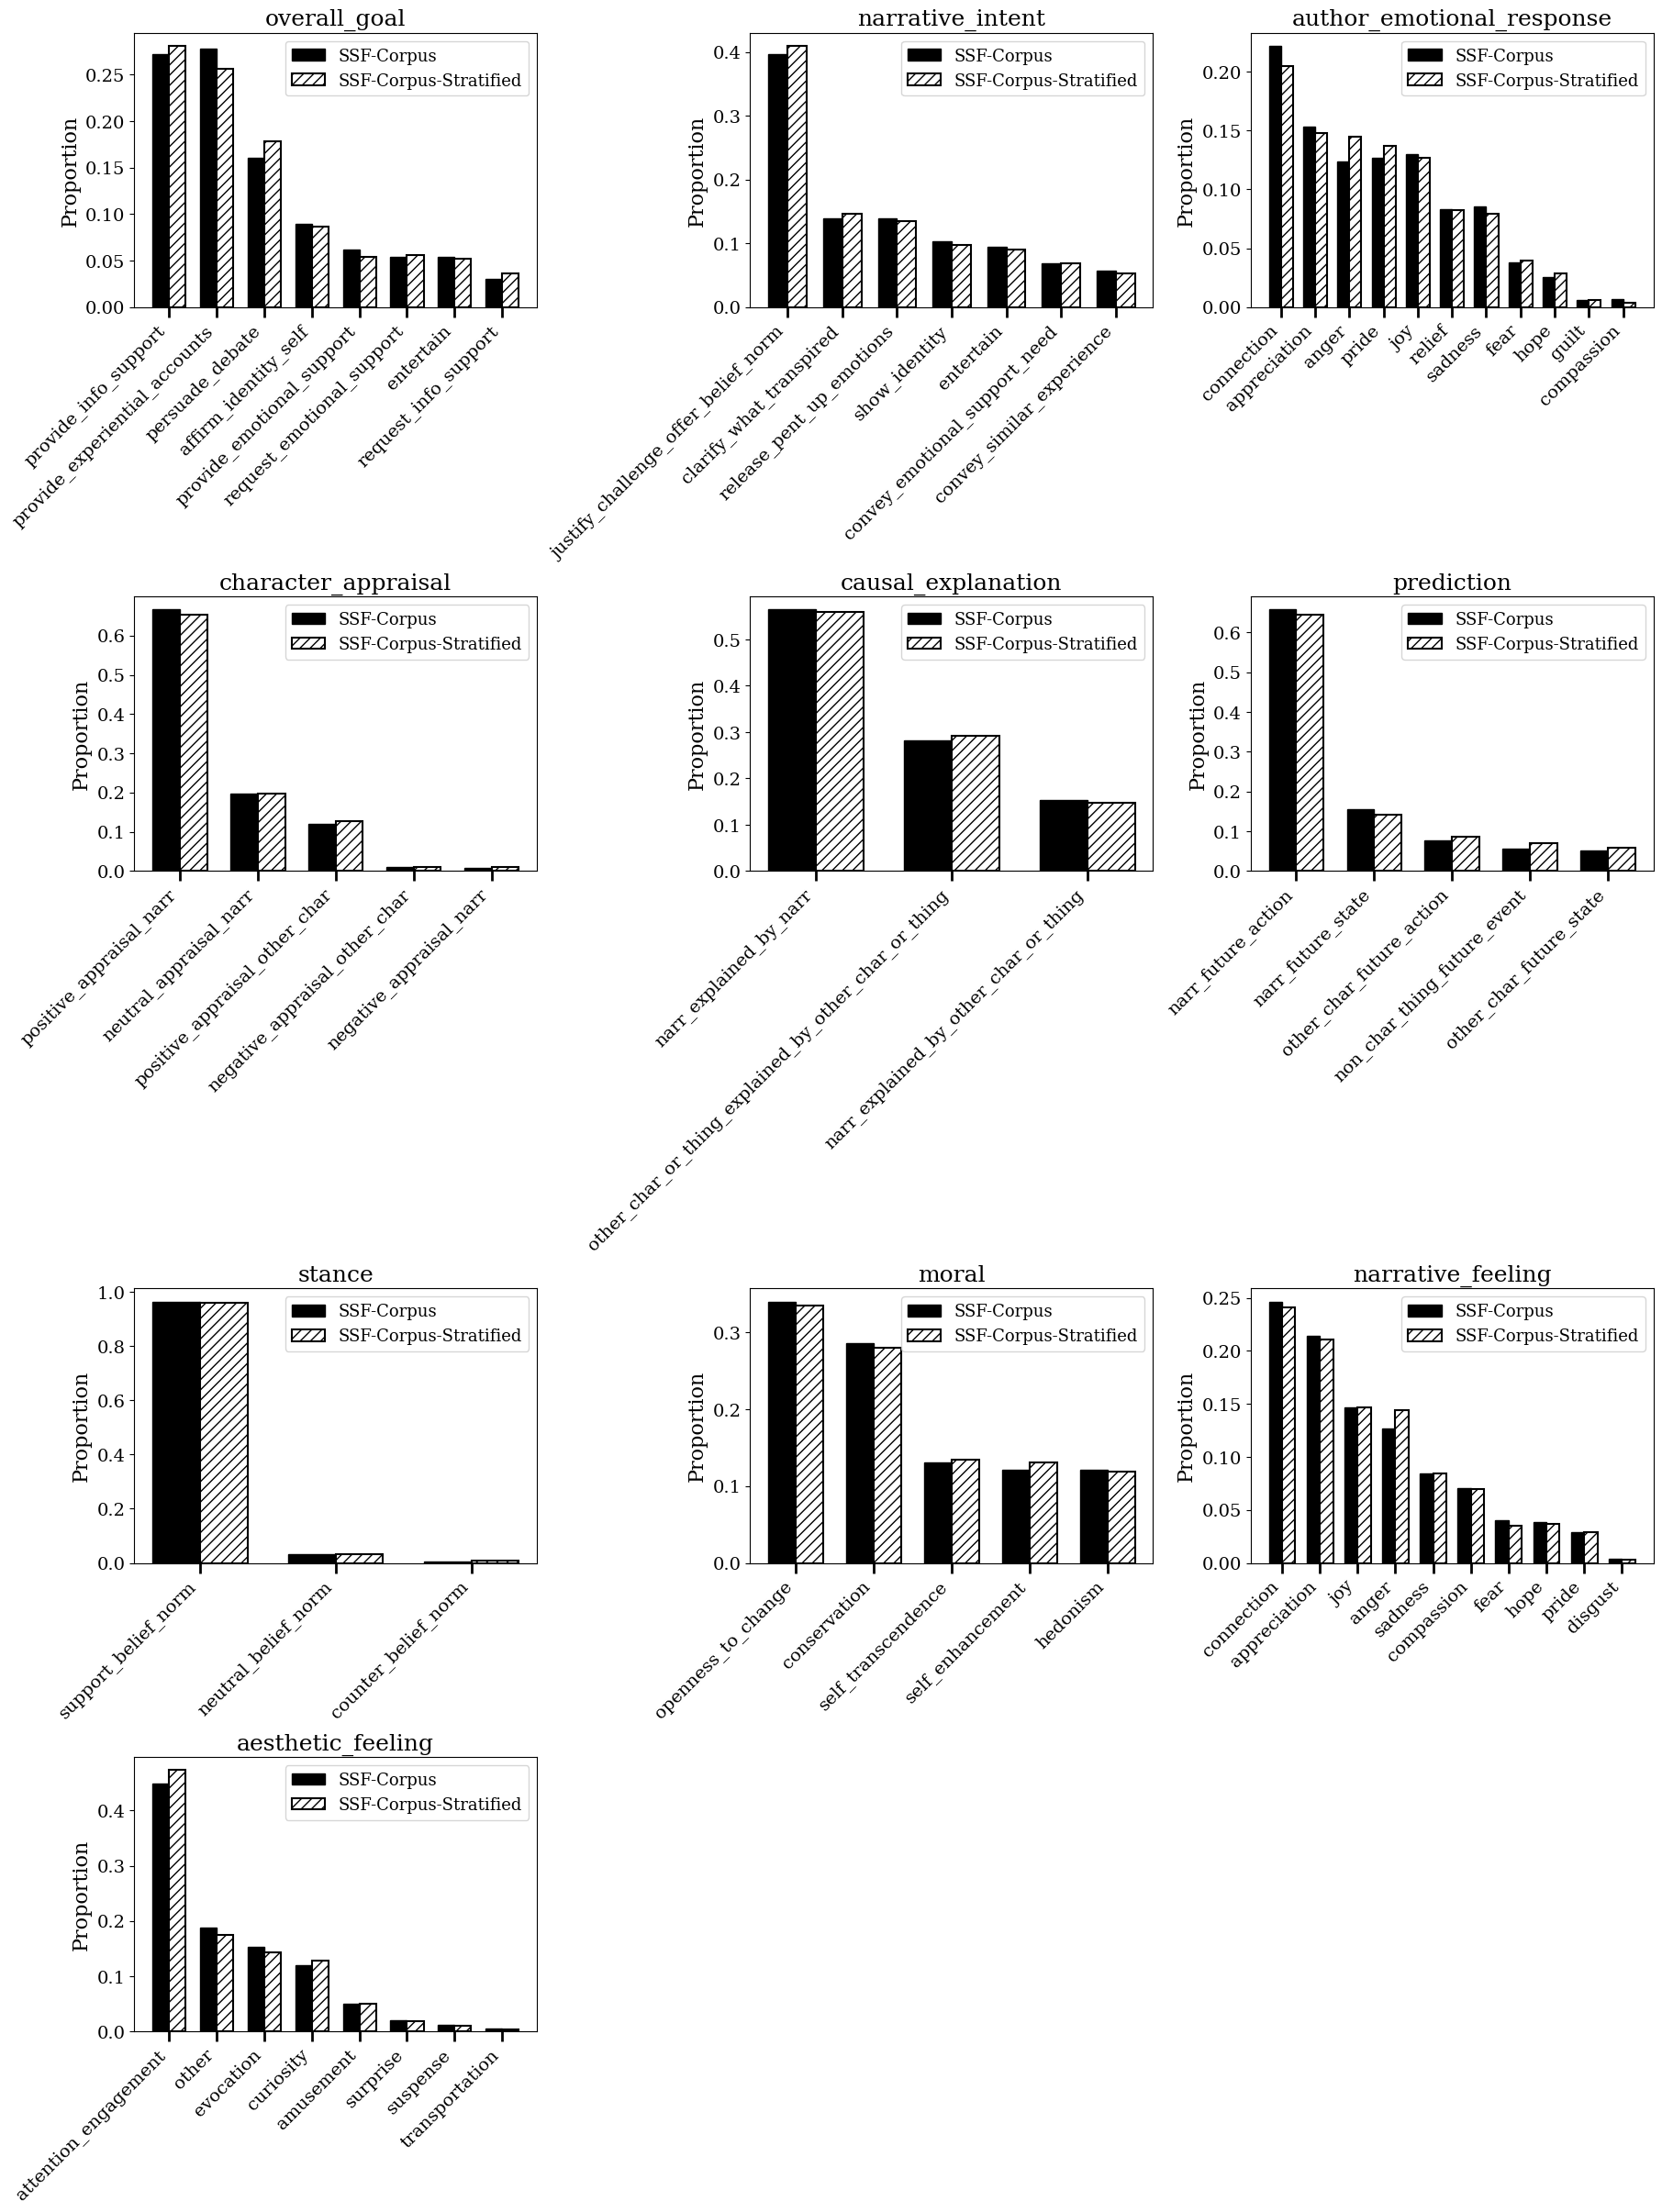

stratified_df shape (2250, 27)


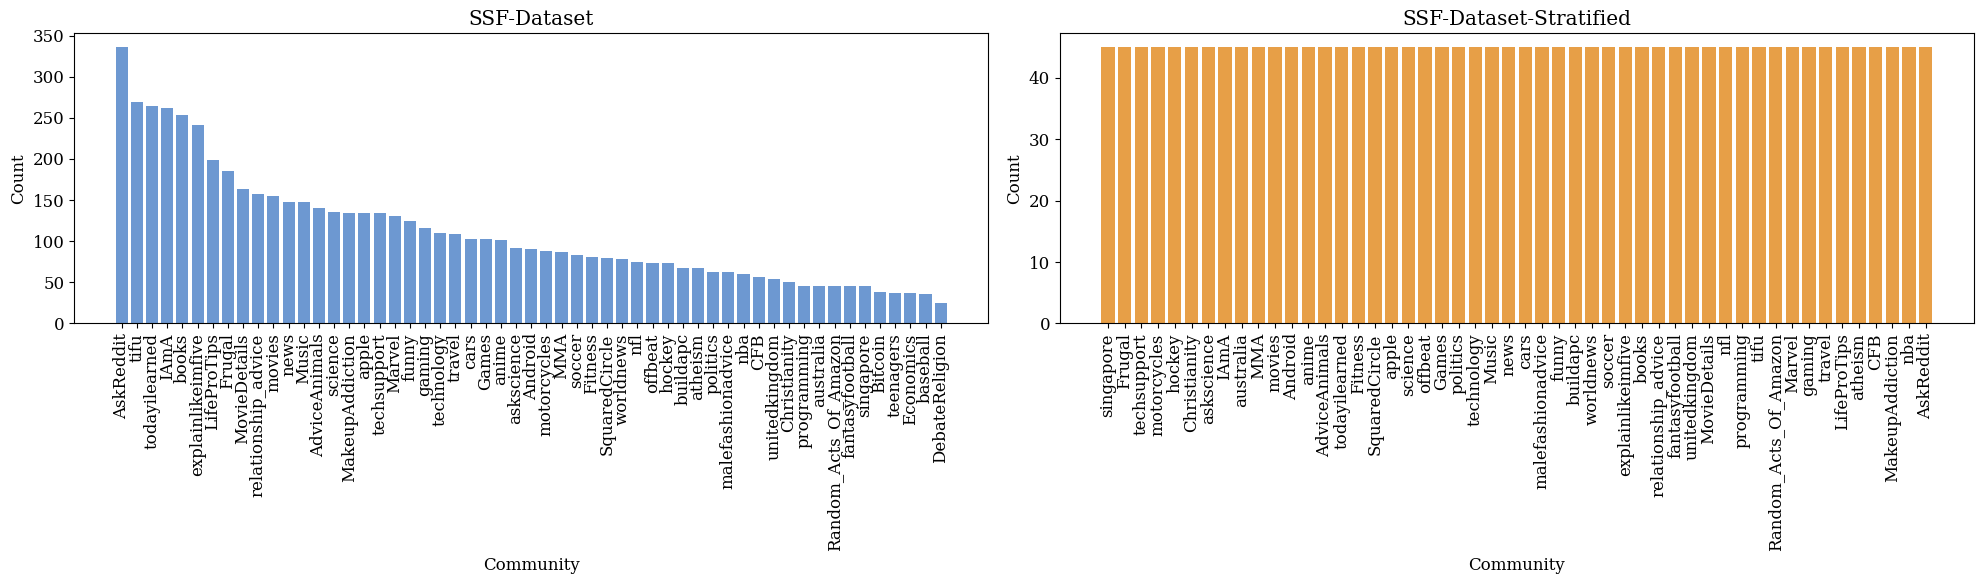

In [11]:
# Import helper functions from centralized modules
from ssf.utils.TaxonomyDataUtils import get_label_counts, get_label_proportions

# Create side-by-side comparisons
print("Creating side-by-side comparisons...")

# One plot per dimension comparing full vs stratified:
# Update subdims to use simplified moral categories
subdims = {dim: list(taxonomy.dim_data_dict[dim].keys()) for dim in taxonomy.get_dims()}
# Override moral subdims with simplified categories
subdims['moral'] = ['self_enhancement', 'openness_to_change', 'conservation', 'self_transcendence', 'hedonism', 'other']

# Plot with individual saves enabled
ResultsVisUtils.plot_side_by_side_counts_per_dimension(tc_analysis_df, subdims, filter_col='is_sampled_for_subreddit', save_individual=True)

# Community comparison:
ResultsVisUtils.plot_counts_by_community_comparison(tc_analysis_df, filter_col='is_sampled_for_subreddit')

strat_df = tc_analysis_df[tc_analysis_df['is_sampled_for_subreddit'] == True]

##### Inter-dimension Associations (NPMI)

In [12]:
subdims = {}
for dim in taxonomy.get_dims():
    if dim == 'moral':
        # For moral dimension, get the mapped categories directly
        original_moral_cats = [cat for cat in taxonomy.dim_data_dict[dim].keys() if cat not in taxonomy.get_excluded_categories(dim)]
        mapped_cats = map_moral_values(original_moral_cats)
        subdims[dim] = list(set(mapped_cats))  # Remove duplicates
    else:
        # For other dimensions, use original approach
        sublabel_support = get_sublabel_support(taxonomy, dim, allow_other=True)
        subdims[dim] = filter_sublabels(taxonomy.dim_data_dict[dim].keys(), sublabel_support)

print(subdims)
npmi_mat_dict = {}
for dim1 in taxonomy.get_dims():
    for dim2 in taxonomy.get_dims():
        key = f"{dim1}${dim2}"
        if f"{dim2}${dim1}" not in npmi_mat_dict:
            npmi_mat_dict[key] = compute_npmi(tc_analysis_df, dim1, dim2, subdims)

to_print = []
dims = taxonomy.get_dims()
for dim1 in dims:
    for dim2 in dims:
        to_print.append(f"{dim1}${dim2}")

# Plot both regular and clustered versions
for key in to_print:
    if key in npmi_mat_dict:
        matrix = npmi_mat_dict[key]

        # Plot regular version
        ResultsVisUtils.plot_npmi_heatmap(matrix, key, clustered=False)

        # Plot clustered version
        ResultsVisUtils.plot_npmi_heatmap(matrix, key, clustered=True)

{'overall_goal': ['request_info_support', 'provide_info_support', 'request_emotional_support', 'provide_emotional_support', 'affirm_identity_self', 'provide_experiential_accounts', 'persuade_debate', 'entertain'], 'narrative_intent': ['show_identity', 'justify_challenge_offer_belief_norm', 'entertain', 'release_pent_up_emotions', 'convey_emotional_support_need', 'convey_similar_experience', 'clarify_what_transpired'], 'author_emotional_response': ['fear', 'guilt', 'anger', 'sadness', 'joy', 'pride', 'relief', 'hope', 'compassion', 'appreciation', 'connection'], 'character_appraisal': ['positive_appraisal_narr', 'negative_appraisal_narr', 'neutral_appraisal_narr', 'positive_appraisal_other_char', 'negative_appraisal_other_char', 'neutral_appraisal_other_narr'], 'causal_explanation': ['narr_explained_by_narr', 'narr_explained_by_other_char_or_thing', 'other_char_or_thing_explained_by_other_char_or_thing'], 'prediction': ['narr_future_state', 'narr_future_action', 'other_char_future_state

/home/jmire/ssf/.venv/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/jmire/ssf/.venv/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/home/jmire/ssf/.venv/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/jmire/ssf/.venv/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/home/jmire/ssf/.venv/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/home/jmire/ssf/.venv/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/home/jmire/ssf/.venv/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin =

### Subreddit Similarity

In [13]:
stratified_tc_analysis_df = tc_analysis_df[tc_analysis_df['have_enough_subreddit_data'] == True]
print(stratified_tc_analysis_df.shape)

def get_subreddits(tc_analysis_df):
  return sorted(tc_analysis_df['subreddit'].unique())

(5967, 27)


In [14]:

def get_semantic_sim_df(tc_analysis_df, st_encoder):
  unnormalized_embeddings = st_encoder.encode(
    tc_analysis_df["text"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False)   # we will normalize after mean pooling by subreddit
  tc_analysis_df['unnormalized_embedding'] = list(unnormalized_embeddings)
  subreddit_mean_embeddings = (
    tc_analysis_df
    .groupby("subreddit")["unnormalized_embedding"]
    .apply(lambda rows: np.mean(np.vstack(rows), axis=0))
    .apply(lambda x: x / np.linalg.norm(x))
  )
  subreddit_order = sorted(subreddit_mean_embeddings.index)  # sort alphabetically for consistent ordering to other similarity dfs
  subreddit_mean_embeddings = subreddit_mean_embeddings.reindex(subreddit_order)
  subreddit_mean_embeddings_matrix = np.vstack(subreddit_mean_embeddings.values)
  return pd.DataFrame(
    cosine_similarity(X=subreddit_mean_embeddings_matrix),
    index=subreddit_order,
    columns=subreddit_order
  )

st_encoder = SentenceTransformer(config.models.sbert_model)

semantic_sim_df = get_semantic_sim_df(tc_analysis_df=stratified_tc_analysis_df,
                                                    st_encoder=st_encoder)
semantic_sim_df.to_csv(f"{config.dirs.data.similarity}/semantic_sim.csv")

Batches: 100%|██████████| 94/94 [00:02<00:00, 44.43it/s]
/tmp/ipykernel_692713/2116349109.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tc_analysis_df['unnormalized_embedding'] = list(unnormalized_embeddings)


Plot saved to: ../results/similarity/subreddit_similarity.pdf


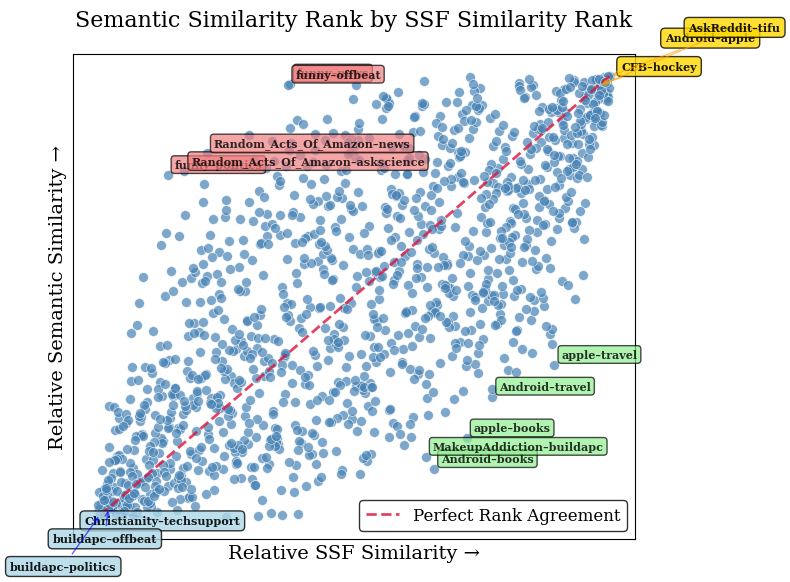

Correlation Analysis: SSF Similarity vs Semantic Similarity
Spearman ρ = 0.736, p = 3.4e-209

Top 5 pairs where SSF Similarity ranks higher than Semantic Similarity:
1. Android <-> books: Rank gap = +671
2. apple <-> travel: Rank gap = +670
3. apple <-> books: Rank gap = +664
4. MakeupAddiction <-> buildapc: Rank gap = +617
5. Android <-> travel: Rank gap = +609

Top 5 pairs where Semantic Similarity ranks higher than SSF Similarity:
1. funny <-> politics: Rank gap = -783
2. Random_Acts_Of_Amazon <-> askscience: Rank gap = -754
3. Random_Acts_Of_Amazon <-> news: Rank gap = -749
4. funny <-> news: Rank gap = -745
5. funny <-> offbeat: Rank gap = -745

Top 3 pairs with strong agreement on HIGH similarity:
1. CFB <-> hockey: Rank gap = +0
2. Android <-> apple: Rank gap = +1
3. AskReddit <-> tifu: Rank gap = +2

Top 3 pairs with strong agreement on LOW similarity:
1. Christianity <-> techsupport: Rank gap = -1
2. buildapc <-> offbeat: Rank gap = -2
3. buildapc <-> politics: Rank gap = -2



In [15]:
# Clean SSF-Sim computation with new column naming
sim_calculator = CommunitySsfSim(taxonomy, lambda_param=0.667)
sublabel_counts = build_community_sublabel_counts(stratified_tc_analysis_df, taxonomy, 'subreddit')
varvals_list = build_community_varvals_list(stratified_tc_analysis_df, taxonomy, 'subreddit')
sim_matrix = sim_calculator.compute_similarity(sublabel_counts, varvals_list)
sim_matrix.to_csv(f"{config.dirs.data.similarity}/ssf_sim.csv")

ResultsVisUtils.plot_similarity_correlation(sim_matrix, semantic_sim_df,
                            "SSF Similarity", "Semantic Similarity",
                            annotate_top_k=5, annotate_agreement=3,
                            save_path=f"{SIMILARITY_RESULTS_DIR}/subreddit_similarity.pdf")
